In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import re
import ast
import folium
from folium import Choropleth
import statsmodels.api as sm
import statsmodels.formula.api as smf
%matplotlib inline

In [ ]:
# IMPORTANT! My original dataset was huge (~2 GB) and so I took a sample of 10k rows
# below is the commented-out code of what I did and produced an already-sampled dataset that's already
# filtered and on github :)

#citations = pd.read_csv("C:\\Users\\taylor\\Downloads\\parking-citations.csv.zip")
#citations.columns = citations.columns.str.lower().str.replace(" ","_")

#citations['issue_date'] = pd.to_datetime(citations['issue_date'])
#citations['issue_year'] = citations['issue_date'].dt.year

# 2019 only
#citations_2019 = citations[citations['issue_year'] == 2019]

# drop unneded columns
#citations_2019 = citations_2019.drop(['ticket_number','meter_id','rp_state_plate','plate_expiry_date','vin','make','body_style','route','color_description','body_style_description'], axis=1)

#sample_path = "C:\\Users\\taylor\\LA_Parking_Citations_Analysis\\data\\parking_citations_2019_sample.csv"
#citations_2019.sample(n=10000, random_state=42).to_csv(sample_path, index=False)



In [ ]:
# loading up main and helper datasets!
citations = pd.read_csv("C:\\Users\\taylor\\LA_Parking_Citations_Analysis\\data\\parking_citations_2019_sample.csv") # main
neighborhoods = gpd.read_file("C:\\Users\\taylor\\LA_Parking_Citations_Analysis\\data\\LA_Times_Neighborhood_Boundaries.geojson") # helper
meter_amts = pd.read_csv("C:\\Users\\taylor\\LA_Parking_Citations_Analysis\\data\\LADOT_Metered_Parking_Inventory___Policies.csv") # helper
street_types = pd.read_csv("C:\\Users\\taylor\\LA_Parking_Citations_Analysis\\data\\LA_Street_Type.csv") # helper

In [100]:
# DATA CLEANING!
# we will go one dataset at a time :) 


### CITATIONS ###

# CURRENT DATA SIZE - (10,000,14) originally was (105658, 22) but trimmed it down to 2019 and dropped some columns, as shown commented above
citations_2019.shape

# standardizing column names 
citations_2019.columns = citations_2019.columns.str.lower().str.replace(" ","_")

# trimming off the columns that are not needed for analysis
#citations_2019 = citations_2019.drop(['ticket_number','meter_id','rp_state_plate','plate_expiry_date','vin','make','body_style','route','color_description','body_style_description'], axis=1)

# we are only looking at 2019 data
citations_2019 = citations_2019[citations_2019['issue_year'] == 2019]

# split up the issue_date by the month, year, and day of week
citations_2019['issue_date'] = pd.to_datetime(citations_2019['issue_date'])
citations_2019['issue_month'] = citations_2019['issue_date'].dt.month
citations_2019['issue_year'] = citations_2019['issue_date'].dt.year
citations_2019['issue_day_of_week'] = citations_2019['issue_date'].dt.dayofweek #0 - 6 means Monday - Sunday

# dropping marked_time since there's a lot of NAs and we care about what time the citation was issued, not when the car parked
#citations_2019 = citations_2019.drop('marked_time', axis=1)



### NEIGHBORHOODS ###

# ORIGINAL DATA SIZE - (114, 3)
neighborhoods.shape
# standardize column names 
neighborhoods.columns = neighborhoods.columns.str.lower().str.replace(" ","_")
# we only care about the neighborhood name and the geometry for our analysis, so we can drop the rest of the columns
#neighborhoods = neighborhoods.drop(['objectid','shape_area','shape_len','city'], axis=1)




### STREET TYPES ###

# ORIGINAL DATA SIZE - (11385, 16)
street_types.shape

# standardizing column names
street_types.columns = street_types.columns.str.lower()

# something new! we only want designation == Boulevard I, Boulevard II, Avenue I, Avenue II, Avenue III
# why? because these are Arterial (major) streets according to lacity.gov
street_types = street_types[street_types['designation'].isin(['Boulevard I', 'Boulevard II', 'Avenue I', 'Avenue II', 'Avenue III'])]   

         
                                   
### METER AMTS ###

# ORIGINAL DATA SIZE - (34269, 7)
meter_amts.shape
# making all columns lowercase, no spaces for readability
meter_amts.columns = meter_amts.columns.str.lower()
# we only need lattitude and longitude
#meter_amts = meter_amts.drop(['spaceid','metertype','ratetype','raterange','meteredtimelimit'], axis=1)

# make the lat/long into a geometry column for geospatial analysis
#meter_amts['geometry'] = meter_amts['latlng'].apply(lambda row: Point(meter_amts['latlon']))
#meter_amts = gpd.GeoDataFrame(meter_amts, geometry='geometry')


# that's all for the cleaning! :)

KeyError: 'issue_date'

In [ ]:
# creating 3 new variables for dataset

# variable 1: neighborhood
# Use lat/lon to find which neighborhood each citation occurred in
geometry = [Point(xy) for xy in zip(citations_2019['latitude'], citations_2019['longitude'])]
citations_gdf = gpd.GeoDataFrame(citations_2019, geometry=geometry, crs='EPSG:2229')
neighborhoods_projected = neighborhoods.to_crs('EPSG:4326')

# reproject citations to match neighborhoods CRS
citations_gdf = citations_gdf.to_crs('EPSG:4326')

# spatial join - figuring out which neighborhood each citation is in
citations_with_neighborhood = gpd.sjoin(citations_gdf, neighborhoods_projected[['geometry', 'name']], 
                                         how='left', predicate='within')
citations_2019.loc[citations_with_neighborhood.index, 'neighborhood'] = citations_with_neighborhood['name']

# variable 2: major (arterial) street
# get street name (remove numbers) and check if it matches street_types
def extract_street_name(street):
    """Extract the street name, excluding numbers."""
    if pd.isna(street):
        return None
    street_name = re.sub(r'\d+', '', str(street)).strip()
    return street_name

citations_2019['street_name'] = citations_2019['location'].apply(extract_street_name)

street_names_set = set(street_types['stname'].str.strip().unique())

citations_2019['major_street'] = citations_2019['street_name'].apply(
    lambda x: 1 if x in street_names_set else 0
)

# variable 3: amount of meters per neighborhood 
meter_amts['latitude'] = meter_amts['latlng'].apply(lambda x: ast.literal_eval(x)[0])
meter_amts['longitude'] = meter_amts['latlng'].apply(lambda x: ast.literal_eval(x)[1])

# make it a geodataframe
meter_amts_geo = gpd.GeoDataFrame(
    meter_amts,
    geometry=[Point(xy) for xy in zip(meter_amts['longitude'], meter_amts['latitude'])],
    crs='EPSG:4326'
)

# another spatial join - which meters are in which neighborhoods?
meter_amts_with_neighborhood = gpd.sjoin(meter_amts_geo, neighborhoods_projected[['geometry', 'name']], 
                                          how='left', predicate='within')

# count of meters per neighborhood
meters_per_neighborhood = meter_amts_with_neighborhood.groupby('name').size().reset_index(name='amt_of_meters')

if 'amt_of_meters' in citations_2019.columns:
    citations_2019 = citations_2019.drop('amt_of_meters', axis=1)

# merge meter count with citations_2019
citations_2019 = citations_2019.merge(meters_per_neighborhood, 
                                       left_on='neighborhood', 
                                       right_on='name', 
                                       how='left')


if 'name' in citations_2019.columns and 'name' != 'neighborhood':
    citations_2019 = citations_2019.drop('name', axis=1)

# NaN values are now 0
citations_2019['amt_of_meters'] = citations_2019['amt_of_meters'].fillna(0).astype(int)


print(f"\nCitations 2019 shape: {citations_2019.shape}")
print(f"\nNew columns:\n{citations_2019[['neighborhood', 'major_street', 'amt_of_meters']].head()}")

ValueError: assignment destination is read-only

In [ ]:
# dropping unneded columns again!
#citations_2019 = citations_2019.drop(['issue_date', 'amt_of_meters_x','amt_of_meters_y'], axis=1)

# turning some variables into categorical and numeric types for modeling
citations_2019['month'] = citations_2019['issue_month'].astype('category')
citations_2019['day_of_week'] = citations_2019['issue_day_of_week'].astype('category')
citations_2019['neighborhood'] = citations_2019['neighborhood'].astype('category')
citations_2019['major_street'] = citations_2019['major_street'].astype('int')
citations_2019['violation_code'] = citations_2019['violation_code'].astype('category')
citations_2019['agency'] = citations_2019['agency'].astype('category')
citations_2019['color'] = citations_2019['color'].astype('category')
citations_2019['fine_amount'] = citations_2019['fine_amount'].astype('float')
citations_2019['amt_of_meters'] = citations_2019['amt_of_meters'].astype('int')
citations_2019['issue_time'] = pd.to_numeric(citations_2019['issue_time'], errors='coerce').astype('Int64')

# full dataset has been made :) - let's see 
citations_2019.head()

,issue_time,color,location,agency,violation_code,violation_description,fine_amount,latitude,longitude,agency_description,issue_year,issue_month,issue_day_of_week,neighborhood,street_name,major_street,amt_of_meters,month,day_of_week
0,805,GY,101 GRANVILLE AVE,51.0,5200,DISPLAY OF PLATES,25.0,6.418800e+06,1.845918e+06,NaN,2019,7,3,Brentwood,GRANVILLE AVE,0,407,7,3
1,1205,BK,1056 SANBORN AVE N,54.0,80.58L,PREFERENTIAL PARKING,68.0,6.476594e+06,1.855799e+06,NaN,2019,3,6,Silver Lake,SANBORN AVE N,0,481,3,6
2,1243,GY,11900 SAN VICENTE BL,51.0,80.56E1,WHITE ZONE,58.0,6.418424e+06,1.841659e+06,51 - DOT - WESTERN,2019,10,5,Brentwood,SAN VICENTE BL,0,407,10,5
3,1102,WT,2200 WESTWOOD BL,51.0,88.13B+,METER EXP.,63.0,6.430877e+06,1.838632e+06,NaN,2019,1,5,West Los Angeles,WESTWOOD BL,0,587,1,5
4,1209,SL,6925 WHITSETT AVE,53.0,80.69BS,NO PARK/STREET CLEAN,73.0,6.439123e+06,1.894105e+06,NaN,2019,2,3,Valley Glen,WHITSETT AVE,0,0,2,3


In [ ]:
### DATA MODELING - NEIGHBORHOOD-LEVEL AGGREGATION
# goal: aggregate citations by neighborhood and build a negative binomial regression model
# predicting citation count using aggregated variables including the categorical variables


# neighborhood-level dataset
neighborhood_agg = citations_2019.groupby('neighborhood', as_index=False).agg({
    'violation_code': 'size',  
    'fine_amount': 'mean',
    'major_street': 'mean',  # using proportion of citations on major streets
    'amt_of_meters': 'first', 
    'issue_time': 'mean'
}).rename(columns={'violation_code': 'citation_count'})

# for categorical variables, get proportions 
# proportion by each month
month_props = pd.crosstab(citations_2019['neighborhood'], citations_2019['month'], normalize='index')
month_props.columns = [f'month_{int(i)}' for i in range(month_props.shape[1])]
neighborhood_agg = neighborhood_agg.merge(month_props, left_on='neighborhood', right_index=True, how='left')

#  proportion by each day
day_props = pd.crosstab(citations_2019['neighborhood'], citations_2019['day_of_week'], normalize='index')
day_props.columns = [f'day_{int(i)}' for i in range(day_props.shape[1])]
neighborhood_agg = neighborhood_agg.merge(day_props, left_on='neighborhood', right_index=True, how='left')

# proportion by each color
color_props = pd.crosstab(citations_2019['neighborhood'], citations_2019['color'], normalize='index')
color_props.columns = [f'color_{int(i)}' for i in range(color_props.shape[1])]
neighborhood_agg = neighborhood_agg.merge(color_props, left_on='neighborhood', right_index=True, how='left')

# proportion by agency
agency_props = pd.crosstab(citations_2019['neighborhood'], citations_2019['agency'], normalize='index')
agency_props.columns = [f'agency_{int(i)}' for i in range(agency_props.shape[1])]
neighborhood_agg = neighborhood_agg.merge(agency_props, left_on='neighborhood', right_index=True, how='left')

# proportion by violation type
top_violations = citations_2019['violation_code'].value_counts().head(8).index
violation_props = pd.crosstab(citations_2019['neighborhood'], citations_2019['violation_code'], normalize='index')[top_violations]
violation_props.columns = [f'violation_{int(i)}' for i in range(violation_props.shape[1])]
neighborhood_agg = neighborhood_agg.merge(violation_props, left_on='neighborhood', right_index=True, how='left')

# all missing prroportions are 0
neighborhood_agg = neighborhood_agg.fillna(0)

print(f"Neighborhood-level dataset shape: {neighborhood_agg.shape}")
print(f"\nNeighborhoods included: {neighborhood_agg['neighborhood'].nunique()}")
print(f"\nSample of aggregated data:")
print(neighborhood_agg.head())
print(f"\nColumn names: {list(neighborhood_agg.columns)}")


Neighborhood-level dataset shape: (111, 75)

Neighborhoods included: 111

Sample of aggregated data:
             neighborhood  citation_count  fine_amount  major_street  \
0         Adams-Normandie              17    75.941176           0.0   
1                  Arleta              17    69.588235           0.0   
2       Arlington Heights              58    74.189655           0.0   
3         Atwater Village              66    66.954545           0.0   
4  Baldwin Hills/Crenshaw              38    76.342105           0.0   

   amt_of_meters   issue_time   month_0   month_1   month_2   month_3  ...  \
0             61   890.352941  0.117647  0.176471  0.058824  0.235294  ...   
1              0   877.588235  0.058824  0.176471  0.058824  0.176471  ...   
2             71  1035.017241  0.172414  0.103448  0.051724  0.224138  ...   
3            222  1175.181818  0.136364  0.075758  0.196970  0.121212  ...   
4              0   817.421053  0.157895  0.078947  0.131579  0.131579  ...  

In [115]:


# NEIGHBORHOOD-LEVEL NEGATIVE BINOMIAL MODEL

# repeat bc an error kept happening without this (?)
if 'neighborhood_agg' not in locals() or neighborhood_agg.shape[0] == 0:
    neighborhood_agg = citations_2019.groupby('neighborhood', as_index=False).agg({
        'violation_code': 'size',
        'fine_amount': 'mean',
        'major_street': 'mean',
        'amt_of_meters': 'first',
        'issue_time': 'mean'
    }).rename(columns={'violation_code': 'citation_count'})

    month_props = pd.crosstab(citations_2019['neighborhood'], citations_2019['month'], normalize='index')
    month_props.columns = [f'month_{int(i)}' for i in range(month_props.shape[1])]
    neighborhood_agg = neighborhood_agg.merge(month_props, left_on='neighborhood', right_index=True, how='left')

    day_props = pd.crosstab(citations_2019['neighborhood'], citations_2019['day_of_week'], normalize='index')
    day_props.columns = [f'day_{int(i)}' for i in range(day_props.shape[1])]
    neighborhood_agg = neighborhood_agg.merge(day_props, left_on='neighborhood', right_index=True, how='left')

    color_props = pd.crosstab(citations_2019['neighborhood'], citations_2019['color'], normalize='index')
    color_props.columns = [f'color_{int(i)}' for i in range(color_props.shape[1])]
    neighborhood_agg = neighborhood_agg.merge(color_props, left_on='neighborhood', right_index=True, how='left')

    agency_props = pd.crosstab(citations_2019['neighborhood'], citations_2019['agency'], normalize='index')
    agency_props.columns = [f'agency_{int(i)}' for i in range(agency_props.shape[1])]
    neighborhood_agg = neighborhood_agg.merge(agency_props, left_on='neighborhood', right_index=True, how='left')

    top_violations = citations_2019['violation_code'].value_counts().head(8).index
    violation_props = pd.crosstab(citations_2019['neighborhood'], citations_2019['violation_code'], normalize='index')[top_violations]
    violation_props.columns = [f'violation_{int(i)}' for i in range(violation_props.shape[1])]
    neighborhood_agg = neighborhood_agg.merge(violation_props, left_on='neighborhood', right_index=True, how='left')

    neighborhood_agg = neighborhood_agg.fillna(0)

# getting proportion column names 
prop_cols = [col for col in neighborhood_agg.columns 
             if col in neighborhood_agg.columns and col not in ['neighborhood', 'citation_count', 'fine_amount', 'major_street', 'amt_of_meters', 'issue_time']]

# create the formula for NB
formula = 'citation_count ~ fine_amount + major_street + amt_of_meters + issue_time + ' + ' + '.join(prop_cols)

print(f"Number of neighborhoods: {neighborhood_agg.shape[0]}")
print(f"Number of proportion predictors: {len(prop_cols)}")
print(f"Total predictors: {len(prop_cols) + 4}")

# fit NB model
nb_model = smf.glm(
    formula=formula,
    data=neighborhood_agg,
    family=sm.families.NegativeBinomial(link=sm.genmod.families.links.Log())
)
nb_results = nb_model.fit()


print("NEIGHBORHOOD-LEVEL NEGATIVE BINOMIAL MODEL")
print("-" * 80)
print(nb_results.summary())


print(f"Number of neighborhoods: {nb_results.nobs}")
print(f"Log-Likelihood: {nb_results.llf:.4f}")
print(f"AIC: {nb_results.aic:.4f}")
print(f"BIC: {nb_results.bic:.4f}")

# top predictors by vairable 
print("\n" + "=" * 80)
print("TOP 15 PREDICTORS (by absolute coefficient value)")
print("-" * 80)
coef_df = pd.DataFrame({
    'Variable': nb_results.params.index,
    'Coefficient': nb_results.params.values,
    'Std Error': nb_results.bse.values,
    'P-value': nb_results.pvalues.values
})
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coef', ascending=False)
print(coef_df[['Variable', 'Coefficient', 'P-value']].head(15))

# the new  predictions
neighborhood_agg['predicted_citation_count'] = nb_results.predict(neighborhood_agg)

print("\n" + "-" * 80)
print("NEIGHBORHOOD PREDICTIONS vs ACTUAL")
print("-" * 80)
print(neighborhood_agg[['neighborhood', 'citation_count', 'predicted_citation_count', 
                        'fine_amount', 'amt_of_meters', 'major_street']].head(111))


Number of neighborhoods: 111
Number of proportion predictors: 70
Total predictors: 74


C:\Users\taylor\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


NEIGHBORHOOD-LEVEL NEGATIVE BINOMIAL MODEL
--------------------------------------------------------------------------------
                 Generalized Linear Model Regression Results                  
Dep. Variable:         citation_count   No. Observations:                  111
Model:                            GLM   Df Residuals:                       40
Model Family:        NegativeBinomial   Df Model:                           70
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -530.68
Date:                Wed, 13 May 2026   Deviance:                       20.882
Time:                        20:05:10   Pearson chi2:                     20.7
No. Iterations:                   100   Pseudo R-squ. (CS):             0.6927
Covariance Type:            nonrobust                                         
                               coef    std err          z      P>|z|      [0.025      

C:\Users\taylor\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\genmod\generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


In [120]:
neighborhood_agg['residual'] = neighborhood_agg['citation_count'] - neighborhood_agg['predicted_citation_count']
neighborhood_agg.head()


,neighborhood,citation_count,fine_amount,major_street,amt_of_meters,issue_time,month_0,month_1,month_2,month_3,...,violation_0,violation_1,violation_2,violation_3,violation_4,violation_5,violation_6,violation_7,predicted_citation_count,residual
0,Adams-Normandie,17,75.941176,0.0,61,890.352941,0.117647,0.176471,0.058824,0.235294,...,0.705882,0.000000,0.176471,0.0,0.000000,0.000000,0.000000,0.000000,20.658658,-3.658658
1,Arleta,17,69.588235,0.0,0,877.588235,0.058824,0.176471,0.058824,0.176471,...,0.529412,0.000000,0.058824,0.0,0.058824,0.000000,0.000000,0.000000,25.187127,-8.187127
2,Arlington Heights,58,74.189655,0.0,71,1035.017241,0.172414,0.103448,0.051724,0.224138,...,0.551724,0.051724,0.120690,0.0,0.017241,0.017241,0.034483,0.000000,53.297599,4.702401
3,Atwater Village,66,66.954545,0.0,222,1175.181818,0.136364,0.075758,0.196970,0.121212,...,0.469697,0.363636,0.015152,0.0,0.030303,0.015152,0.000000,0.015152,72.723012,-6.723012
4,Baldwin Hills/Crenshaw,38,76.342105,0.0,0,817.421053,0.157895,0.078947,0.131579,0.131579,...,0.394737,0.000000,0.263158,0.0,0.026316,0.000000,0.000000,0.000000,38.310307,-0.310307


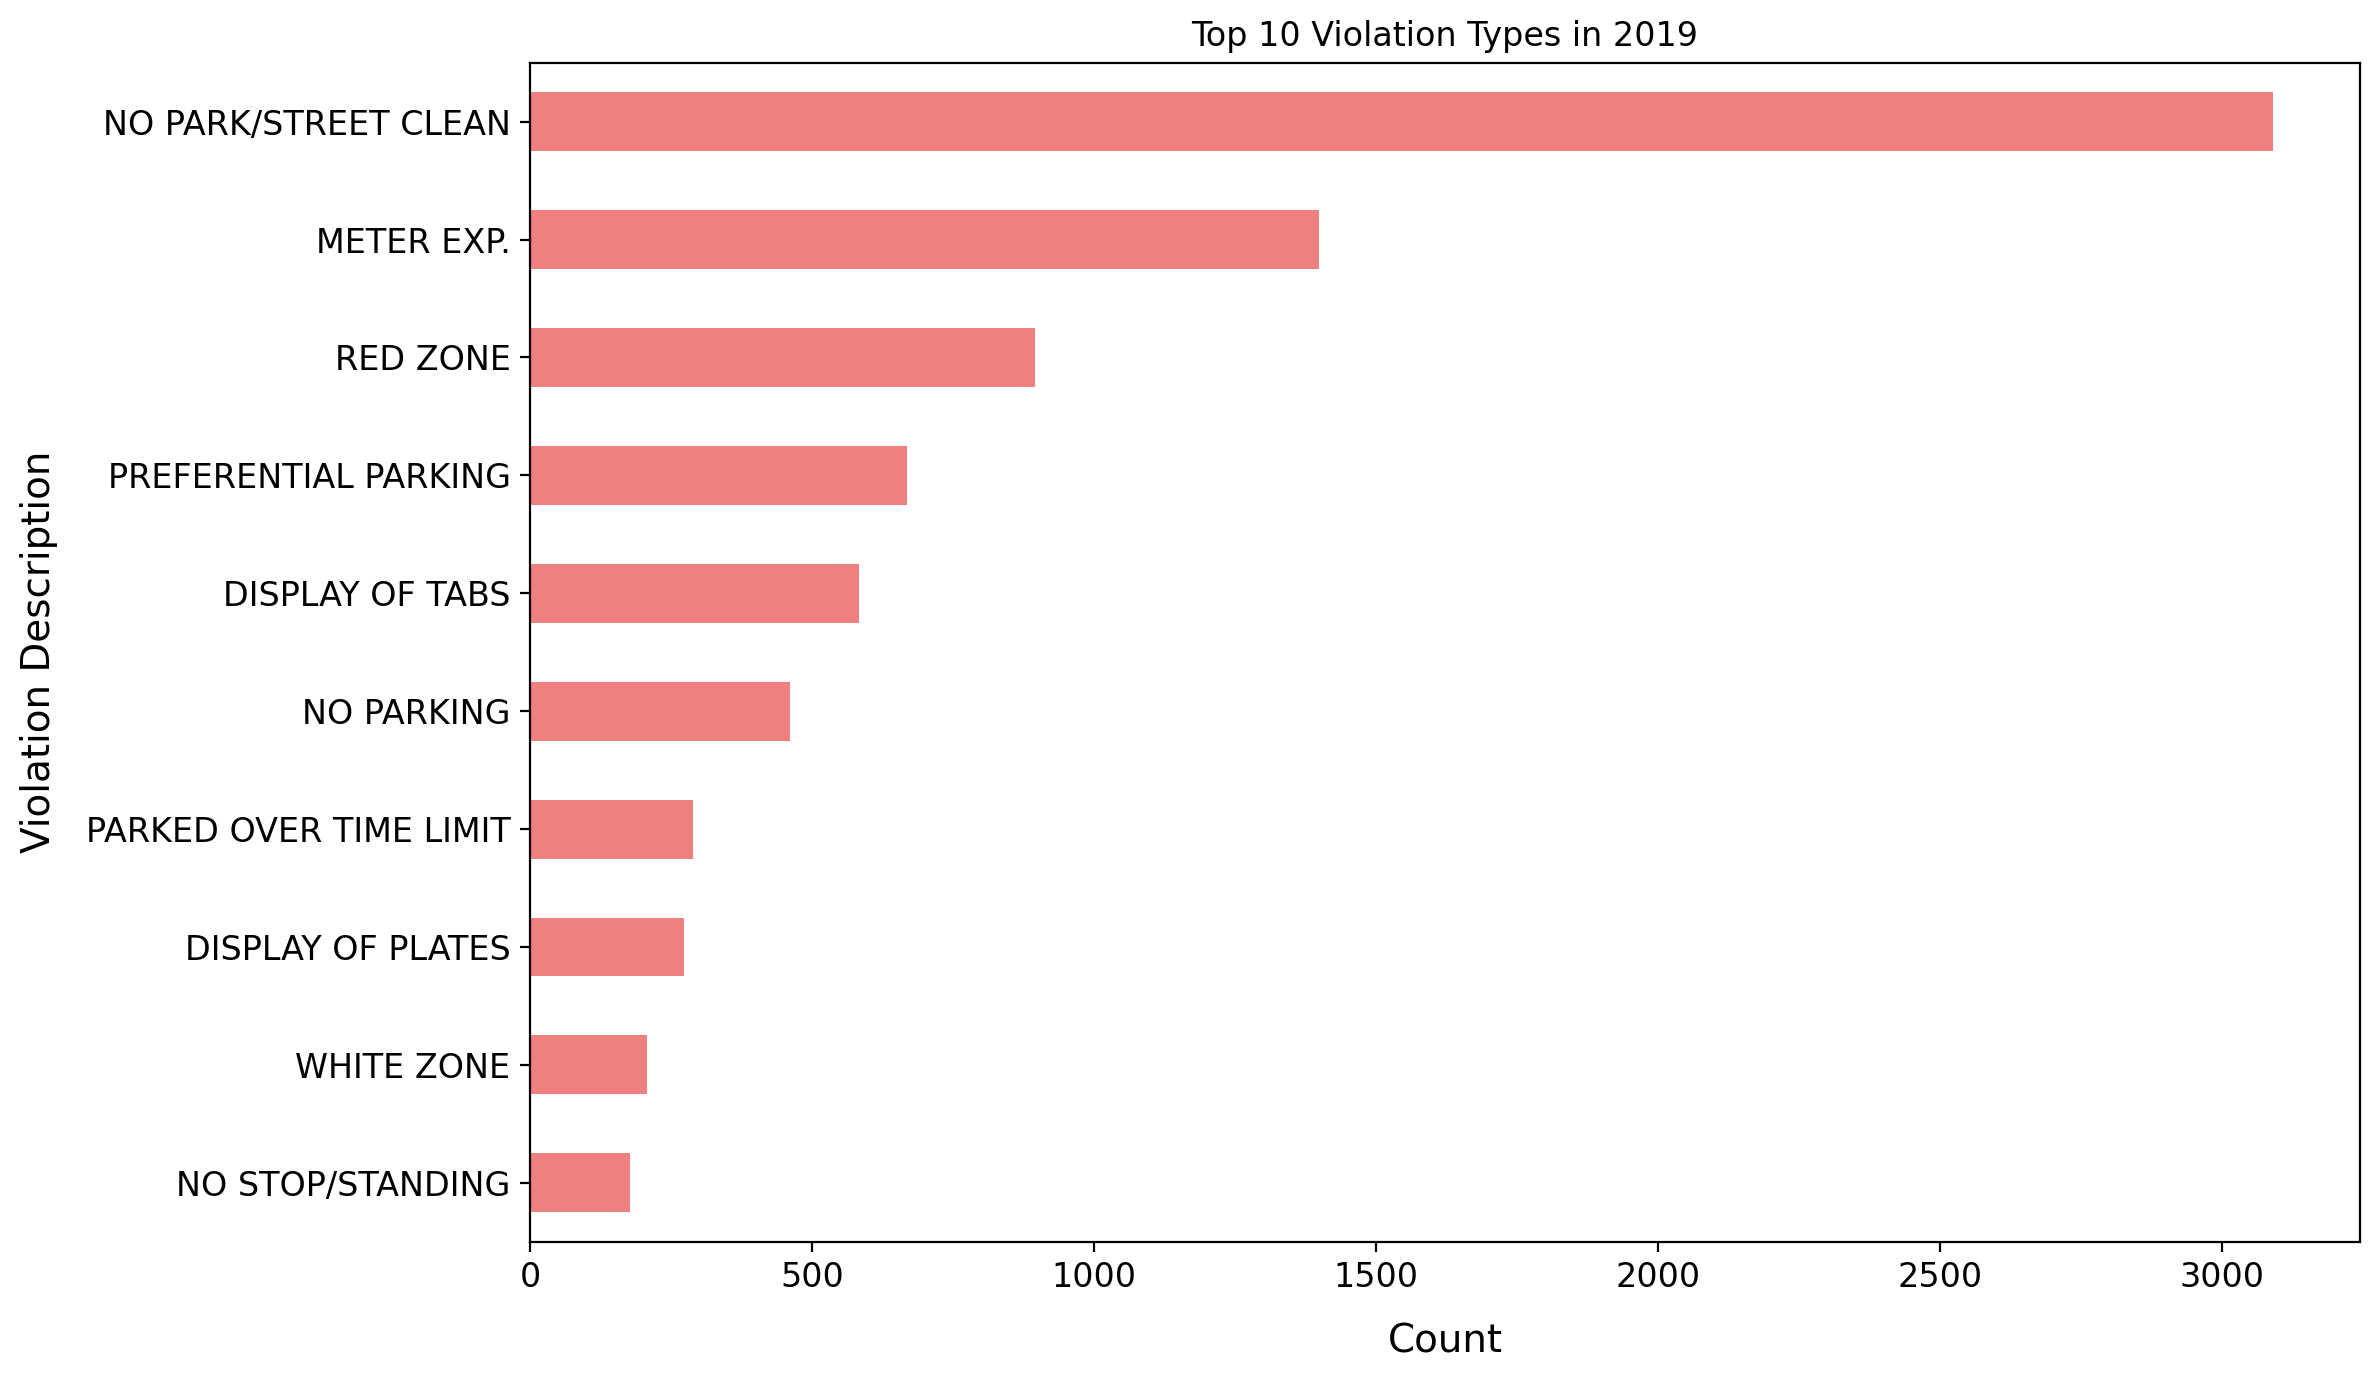

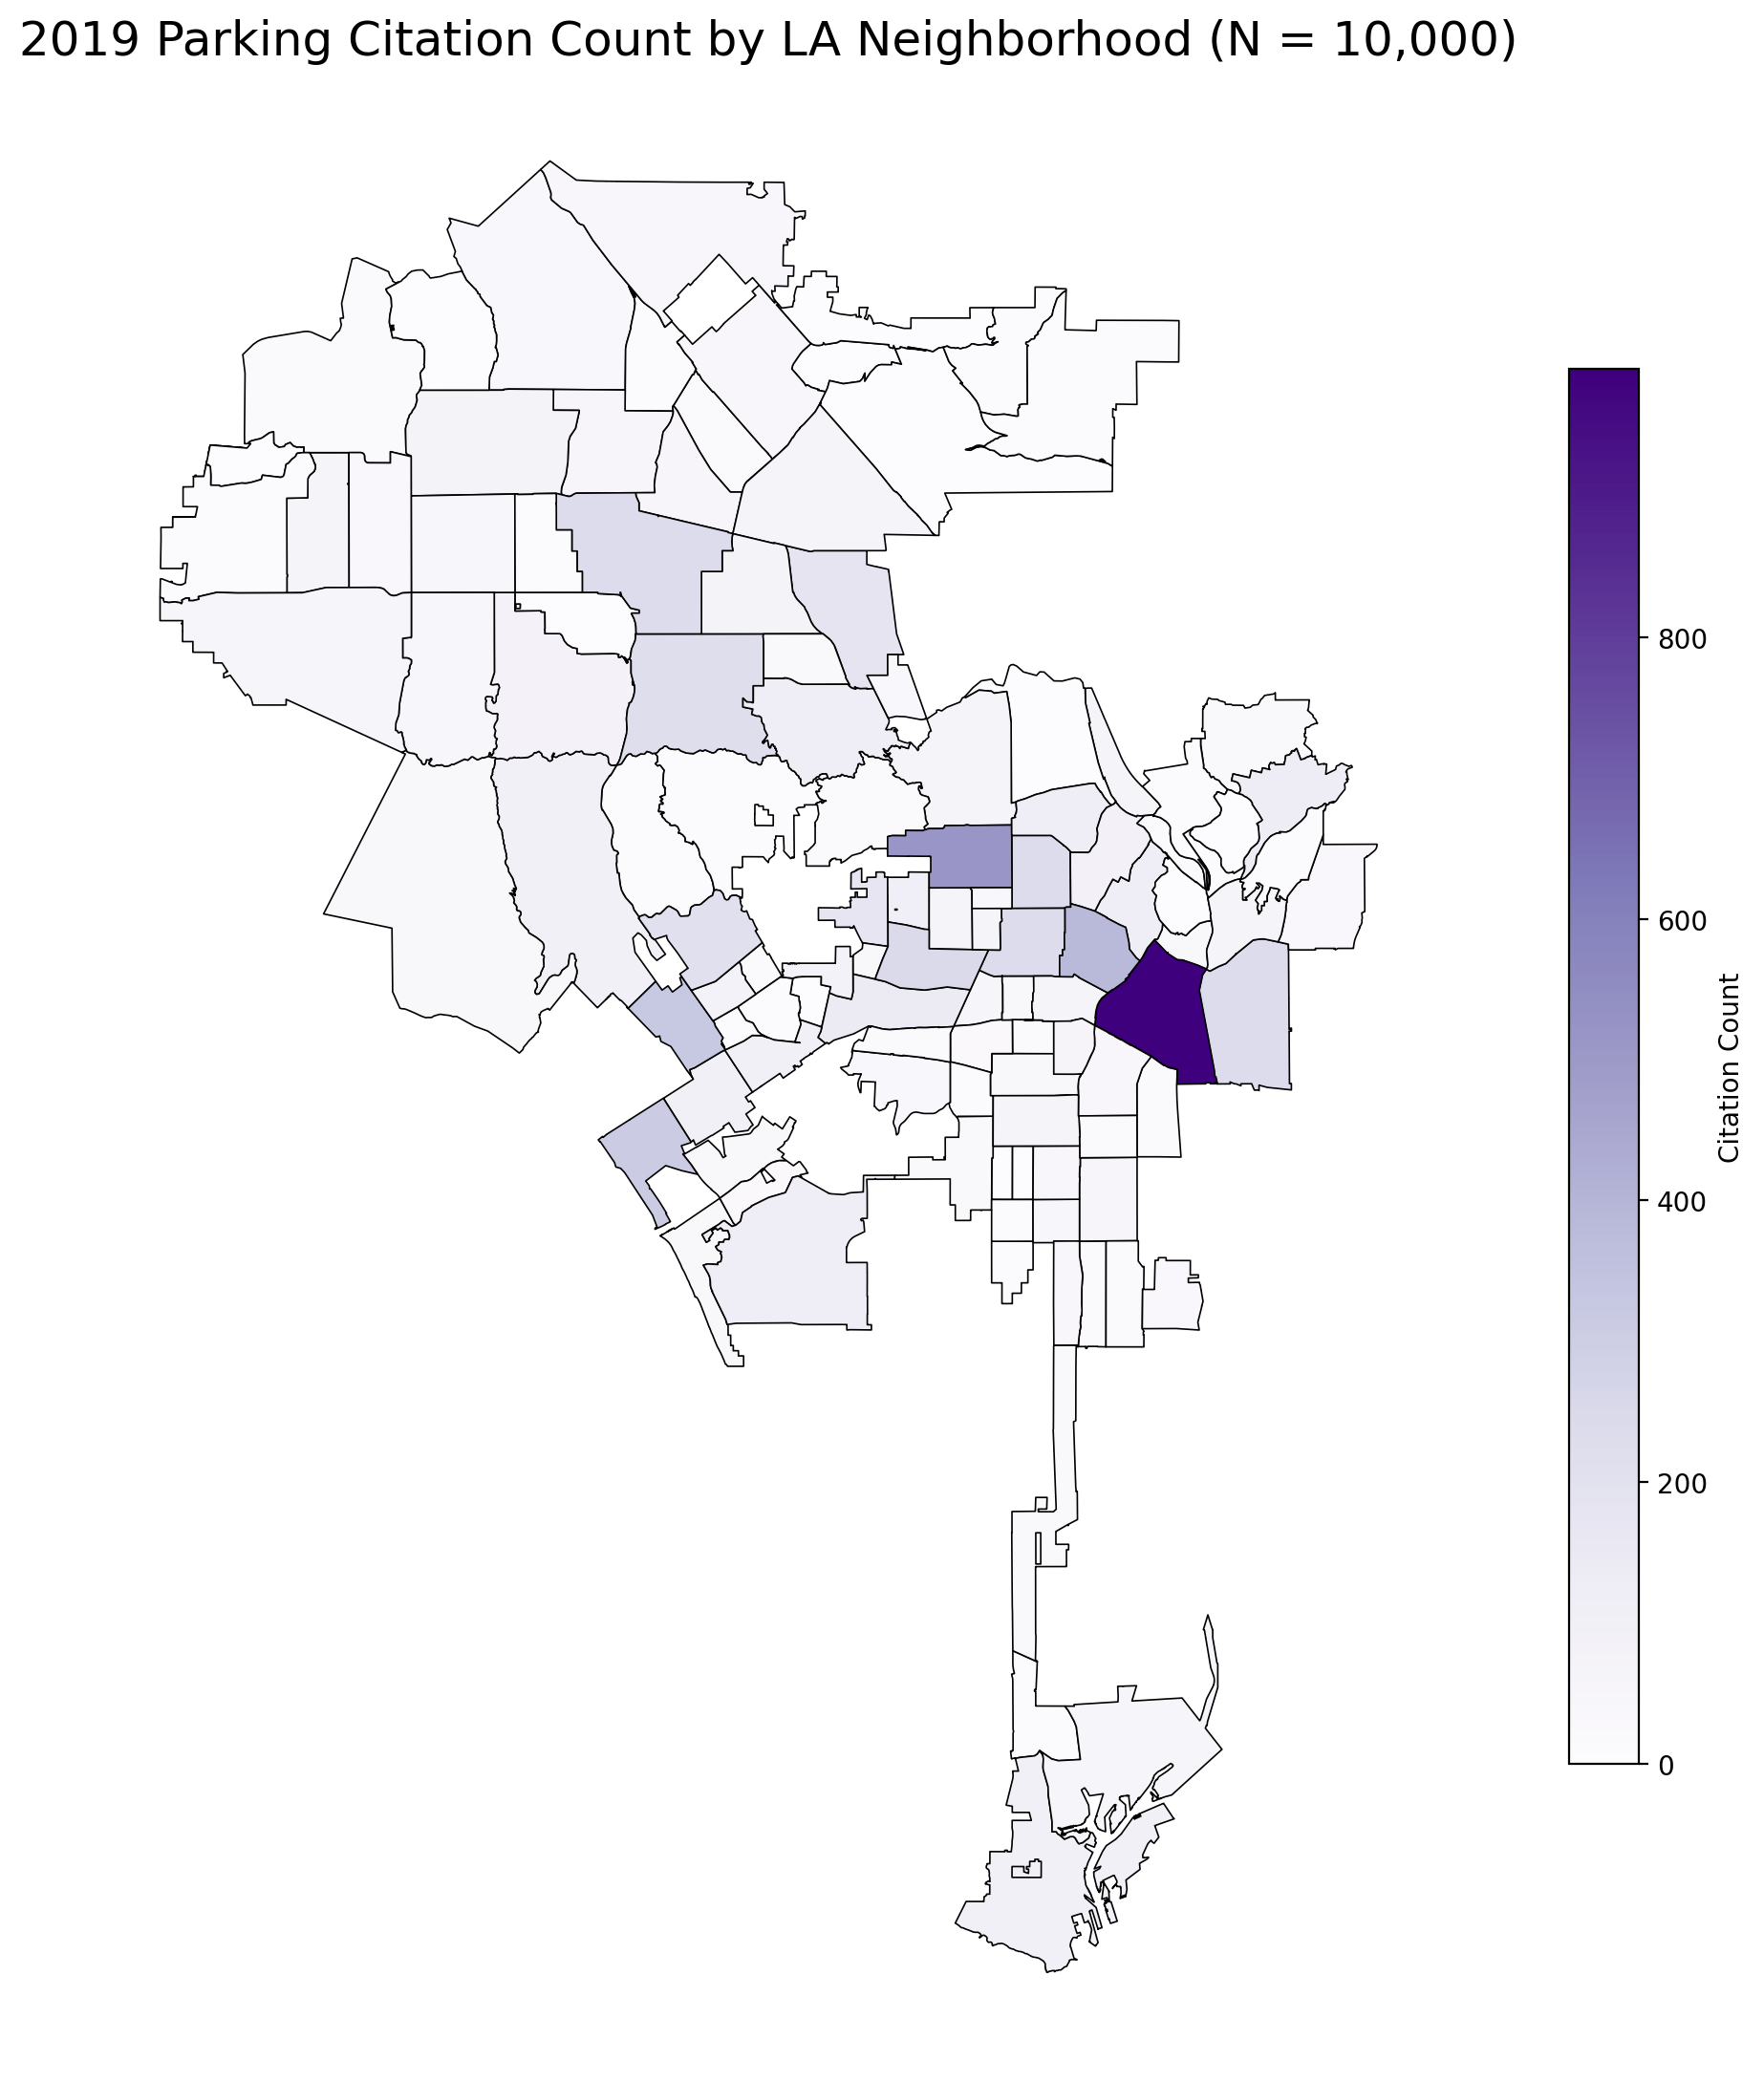

Interactive choropleth map saved as 'la_parking_citations_choropleth.html'. Open this file in a web browser to view the map.


In [105]:
# VISUALIZATIONS !!

# initial distribution of citation type

citation_counts = citations_2019['violation_description'].value_counts().head(10)
citation_counts = citation_counts.sort_values(ascending=False)

colors = ['darkred' if 'No Parking' in label or 'Street Cleaning' in label else 'lightcoral'
          for label in citation_counts.index]

fig, ax = plt.subplots(figsize=(12, 7), dpi=200)
ax = citation_counts.plot(kind='barh', color=colors, ax=ax, title='Top 10 Violation Types in 2019')
ax.set_xlabel('Count', size=14, labelpad=10)
ax.set_ylabel('Violation Description', size=14, labelpad=10)
ax.tick_params(labelsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
fig.savefig('citations_top10_highres.png', dpi=300, bbox_inches='tight')
plt.show()


# choropleth map of neighborhood citation counts
neighborhood_citations = neighborhoods.merge(
    neighborhood_agg[['neighborhood', 'citation_count']],
    left_on='name',
    right_on='neighborhood',
    how='left'
)
neighborhood_citations['citation_count'] = neighborhood_citations['citation_count'].fillna(0)

fig, ax = plt.subplots(figsize=(14, 11), dpi=200)
neighborhood_citations.plot(
    column='citation_count',
    cmap='Purples',
    linewidth=0.6,
    edgecolor='black',
    legend=True,
    legend_kwds={'label': 'Citation Count', 'shrink': 0.7},
    ax=ax
)
ax.set_title('2019 Parking Citation Count by LA Neighborhood (N = 10,000)', fontsize=18)
ax.set_axis_off()
plt.tight_layout()
fig.savefig('la_neighborhood_citations_choropleth_highres.png', dpi=300, bbox_inches='tight')
plt.show()


# interactive chloropleth map that can be opened in new tab

# base map centered on LA
la_map = folium.Map(location=[34.0522, -118.2437], zoom_start=10)

Choropleth(
    geo_data=neighborhood_citations,
    name='choropleth',
    data=neighborhood_citations,
    columns=['name', 'citation_count'],
    key_on='feature.properties.name',
    fill_color='Purples',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='2019 Parking Citation Count'
).add_to(la_map)

folium.LayerControl().add_to(la_map)

# saving to html
la_map.save('la_parking_citations_choropleth.html')
print("Interactive choropleth map saved as 'la_parking_citations_choropleth.html'. Open this file in a web browser to view the map.")
